<a href="https://colab.research.google.com/github/AbrahamB2603/IAyRN/blob/Main/AF8_RNC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Actividad 8: Redes Neuronales Convolucionales
Abraham Giovanni Aguirre Bravo - 2014222 - Martes N4

Ramiro Emiliano Martinez De La Cruz - 2014197 - Martes N4

María Fernanda Garza Barbosa - 1945003 - Martes N4

Karla Judith Corona Castro - 1923390 - Martes N4

# Carga de Librerias

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


# Carga de Datos MNIST

In [16]:
# Datos MNIST
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()


#Pre-procesamiento de Datos

In [17]:
#(0 a 1)
train_data = train_data.astype("float32") / 255.0
test_data = test_data.astype("float32") / 255.0

# Redimension (28x28x1)
train_data = np.expand_dims(train_data, axis=-1)
test_data = np.expand_dims(test_data, axis=-1)

# Etiquetas
train_labels_cat = to_categorical(train_labels, 10)
test_labels_cat = to_categorical(test_labels, 10)


# Seleccion y Entrenamiento del modelo.

In [18]:
# Estructura de la Red
model = Sequential()

# Capa convolucional 1
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Capa convolucional 2
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Capa de aplanamiento
model.add(Flatten())

# Capa densa
model.add(Dense(128, activation='relu'))

# Capa de salida con activación softmax
model.add(Dense(10, activation='softmax'))

In [19]:
# Compilación
model.compile(
    loss='categorical_crossentropy',   # Función de pérdida
    optimizer='adam',                  # Optimizador
    metrics=['accuracy']               # Métrica
)


In [14]:
# Entrenar el modelo
print("Entrenando el modelo...")
model.fit(train_data, train_labels_cat, epochs=5, batch_size=64, validation_split=0.1)

# Evaluar el modelo con el conjunto de prueba
print("\nEvaluando el modelo con datos de prueba...")
test_loss, test_accuracy = model.evaluate(test_data, test_labels_cat, verbose=0)
print(f"Exactitud en datos de prueba: {test_accuracy * 100:.2f}%")


Entrenando el modelo...
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 53s 61ms/step - accuracy: 0.8842 - loss: 0.3843 - val_accuracy: 0.9852 - val_loss: 0.0544
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 77s 55ms/step - accuracy: 0.9845 - loss: 0.0521 - val_accuracy: 0.9898 - val_loss: 0.0360
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 53ms/step - accuracy: 0.9891 - loss: 0.0357 - val_accuracy: 0.9907 - val_loss: 0.0369
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 54ms/step - accuracy: 0.9927 - loss: 0.0218 - val_accuracy: 0.9897 - val_loss: 0.0337
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 53ms/step - accuracy: 0.9946 - loss: 0.0173 - val_accuracy: 0.9903 - val_loss: 0.0391

Evaluando el modelo con datos de prueba...
Exactitud en datos de prueba: 99.11%


#Prueba de Modelo


Predicciones individuales:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


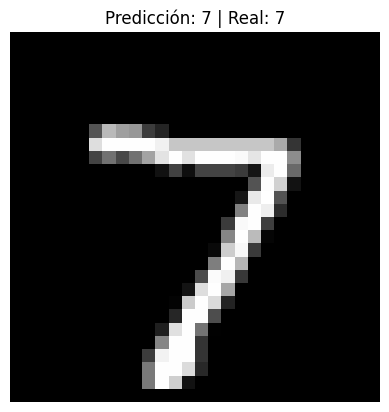

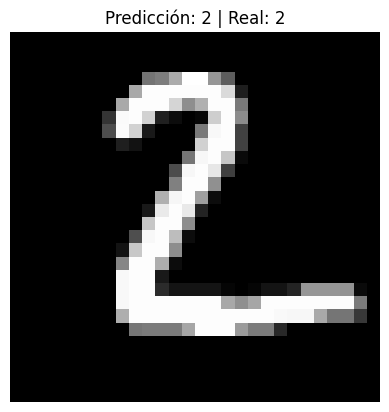

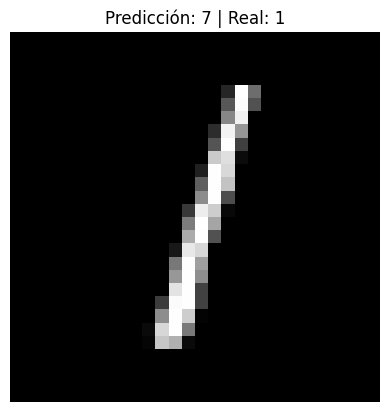

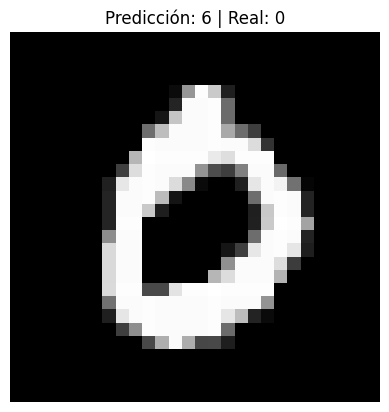

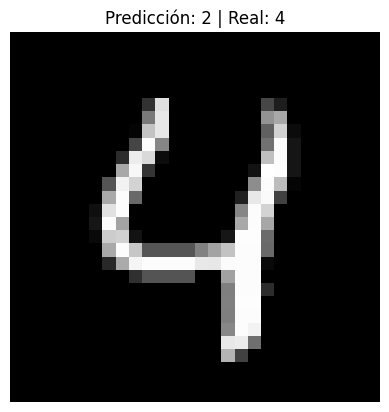

In [20]:
# 5 predicciones de prueba
print("\nPredicciones individuales:")
predictions = model.predict(test_data[:5])
predicted_classes = np.argmax(predictions, axis=1)

# Imágenes, predicciones y valores reales
for i in range(5):
    plt.imshow(test_data[i].reshape(28, 28), cmap="gray")
    plt.title(f"Predicción: {predicted_classes[i]} | Real: {test_labels[i]}")
    plt.axis("off")
    plt.show()

#Responde las preguntas.

¿Cuantas epocas usaste para mejorar el rendimiento del modelo en comparacion con la red neuronal prealimentada de la Act.5?

- Usamos 3 más de las que usamos en la actividad anterior, fue mucho mejor con esta Red


¿Obtuviste un mejor rendimiento con este modelo o con el de la actividad 5?

- Con este modelo de aqui, a mi parecer. Ya que con el anterior se tenian que hacer mas pasos y la programacion era mas extensa, aunque era mas sencilla la programacion en el anterior pero con este modelo tiende a ser mas facil y rapido sin tener que entrenarlo tanto.

#Referencias.

Matthes, E. (2023). Python crash course. No starch press.

https://www.w3schools.com/python/default.asp

Géron, A. (2022). Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow. " O'Reilly Media, Inc."